In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [12]:
TRAIN_DIR = "../dataset/PlantVillage_5Class/train"
VAL_DIR = "../dataset/PlantVillage_5Class/val"

In [20]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 4268 files belonging to 5 classes.
Found 1068 files belonging to 5 classes.


In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [23]:
base_model = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [24]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [25]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_3[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_54       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation_54[0]… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu_42[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_43 (ReLU)     │ (None, 1, 1, 16)  │          0 │ add_27[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_27         │ (None, 1, 1, 16)  │          0 │ re_lu_43[0][0]    │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu_42[0][0],   │
│ (Multiply)          │ 16)               │            │ multiply_27[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,088,117 (4.15 MB)

 Trainable params: 148,997 (582.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

training_time = time.time() - start_time

print("Training Time:", training_time)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 33s 199ms/step - accuracy: 0.9124 - loss: 0.2574 - val_accuracy: 0.9878 - val_loss: 0.0485
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 172ms/step - accuracy: 0.9813 - loss: 0.0621 - val_accuracy: 0.9906 - val_loss: 0.0263
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9866 - loss: 0.0402 - val_accuracy: 0.9897 - val_loss: 0.0264
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.9932 - loss: 0.0261 - val_accuracy: 0.9934 - val_loss: 0.0193
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.9923 - loss: 0.0237 - val_accuracy: 0.9934 - val_loss: 0.0231
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9939 - loss: 0.0179 - val_accuracy: 0.9972 - val_loss: 0.0116
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.9960 - loss: 0.0146 - val_accuracy: 0.9925 - val_loss: 0.0217
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.9960 - loss: 0

In [27]:
loss, accuracy = model.evaluate(val_ds)

print("Accuracy:", accuracy)
print("Loss:", loss)
print("Training Time:", training_time)

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.9981 - loss: 0.0068
Accuracy: 0.9981273412704468
Loss: 0.006773012224584818
Training Time: 397.82150864601135


34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step


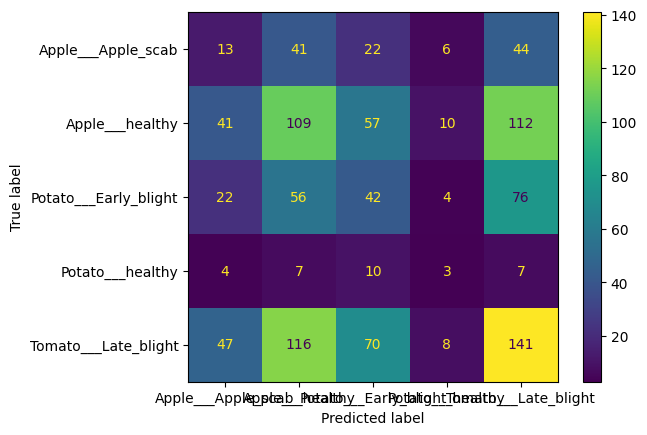

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

y_true = np.concatenate(
    [y for x, y in val_ds],
    axis=0
)

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.show()

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

mAP = average_precision_score(
    y_true_bin,
    predictions,
    average="macro"
)

print("mAP:", mAP)

mAP: 0.21494625633773726


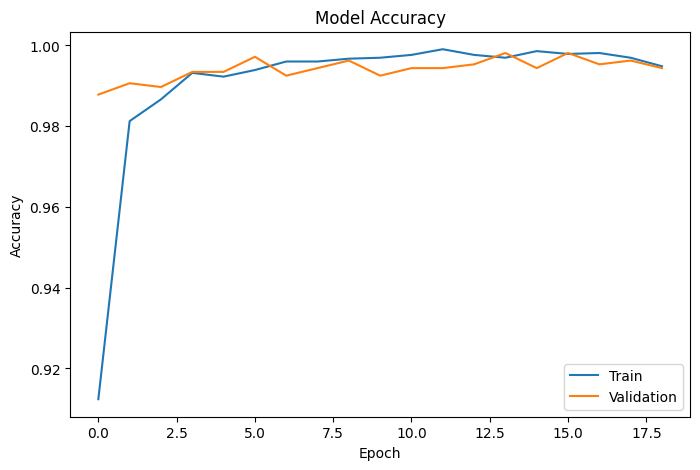

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.savefig("../results/model_accuracy.png")
plt.show()

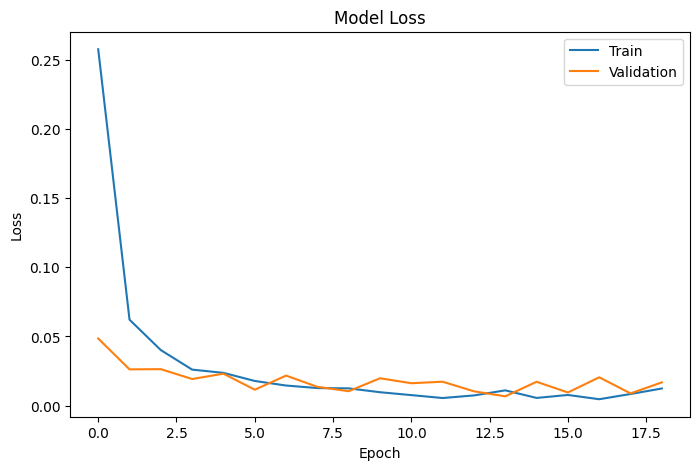

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.savefig("../results/model_loss.png")
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step


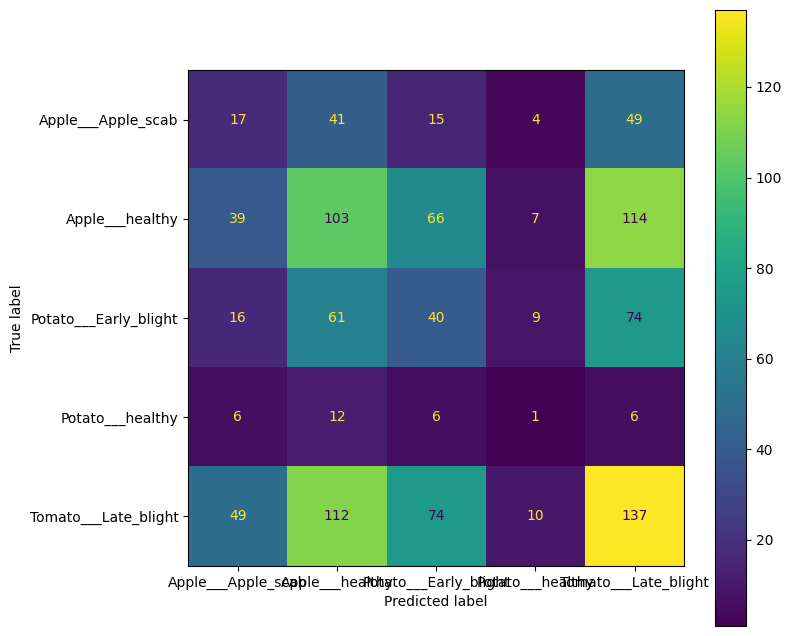

In [33]:
y_true = np.concatenate(
    [y for x, y in val_ds],
    axis=0
)

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)

plt.show()

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

In [35]:
y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

mAP = average_precision_score(
    y_true_bin,
    predictions,
    average="macro"
)

print("mAP:", mAP)

mAP: 0.20254216144338608


In [36]:
model.save("../models/mobilenetv3.keras")

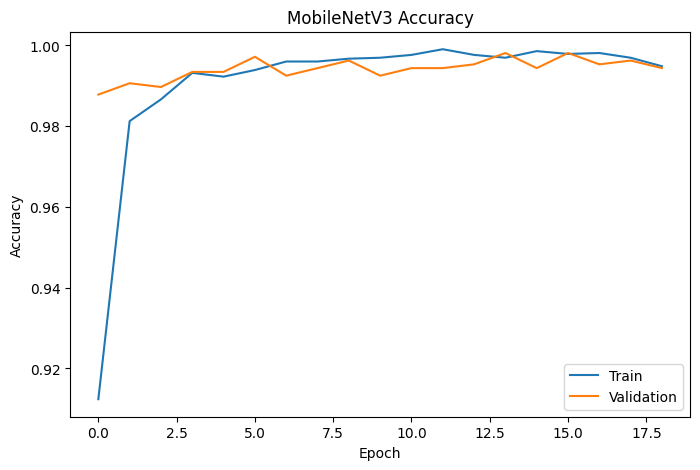

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

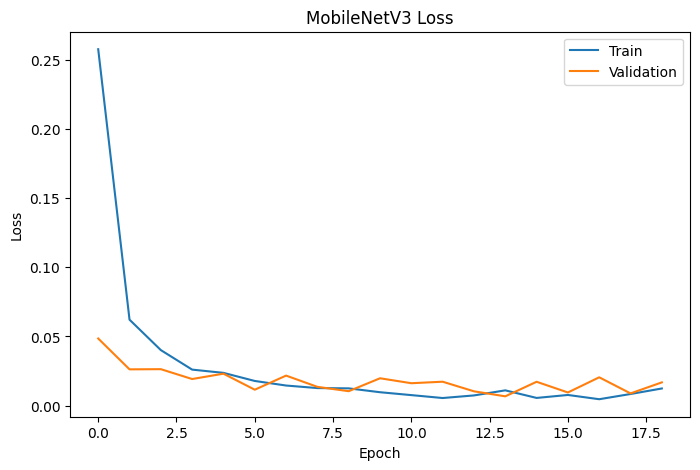

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MobileNetV3 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()